<a href="https://colab.research.google.com/github/marymilad13-design/sentiment_analysis_research/blob/main/sentiment_analysis_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import the NumPy library for numerical operations
import numpy as np

# Import the pyplot module from matplotlib for plotting and visualization
import matplotlib.pyplot as plt

# Import the pandas library for data manipulation and analysis
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets.csv


In [4]:
# Read the CSV file "Tweets.csv" into a pandas DataFrame
df = pd.read_csv('Tweets.csv')

# Display the first five rows of the DataFrame to inspect the data
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Calculate and display the number of samples (rows) in the dataset
num_samples = len(df)

# Calculate and display the number of features (columns), including the target output
num_features = len(df.columns)

# Output the results
print("Number of samples in the dataset:", num_samples)
print("Number of features including:", num_features)

Number of samples in the dataset: 14640
Number of features including: 15


In [6]:
# Calculate the number of unique sentiment classes in the 'airline_sentiment' column
num_classes = len(df["airline_sentiment"].value_counts())

# Display the number of unique sentiment classes
print("number of classes in the dataset:",num_classes)

# Display the count of samples for each sentiment class
print(df["airline_sentiment"].value_counts())

number of classes in the dataset: 3
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [7]:
# Display summary statistics for numerical columns
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [8]:
# See the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [9]:
# Display the number of missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5462
negativereason_confidence,4118
airline,0
airline_sentiment_gold,14600
name,0
negativereason_gold,14608
retweet_count,0


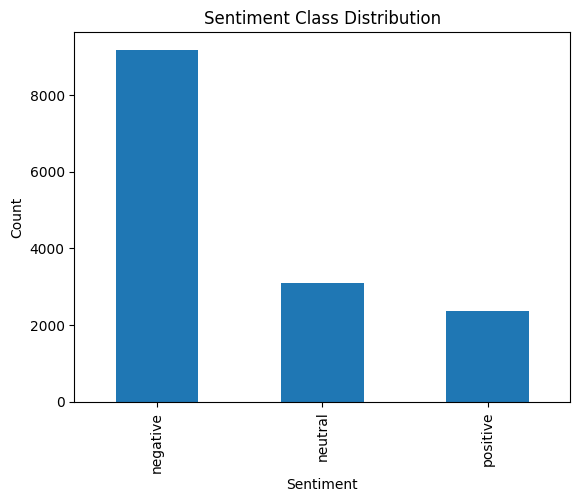

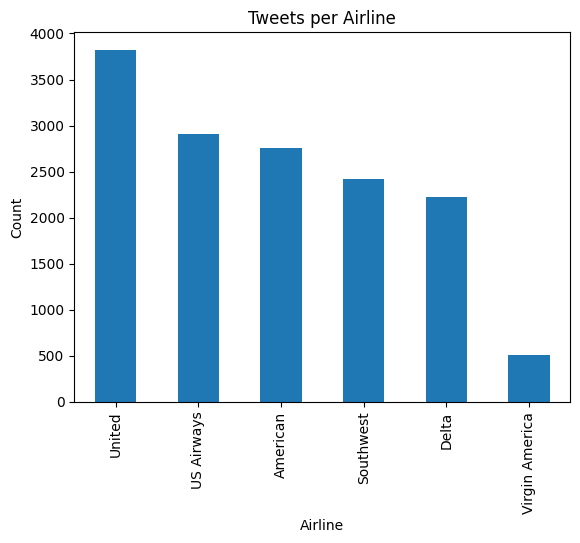

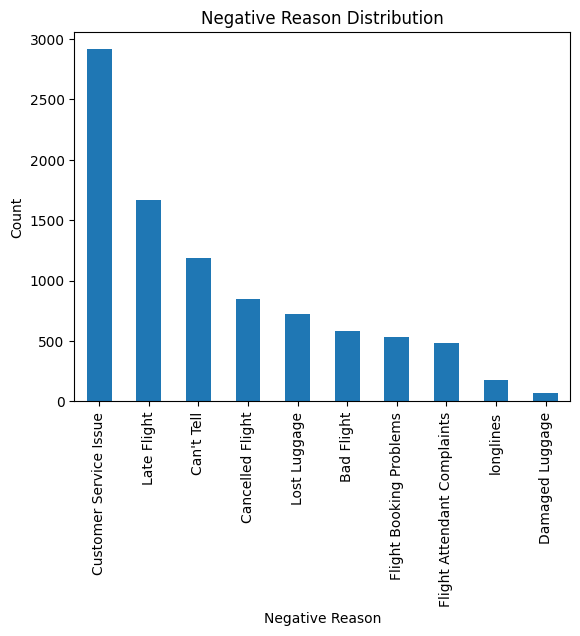

In [10]:
# Visualize the distribution of sentiment classes
df["airline_sentiment"].value_counts().plot(kind='bar', title='Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of tweets per airline
df["airline"].value_counts().plot(kind='bar', title='Tweets per Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

# Visualize the distribution of negative reasons (if available)
if df["negativereason"].notnull().any():
    df["negativereason"].value_counts().plot(kind='bar', title='Negative Reason Distribution')
    plt.xlabel('Negative Reason')
    plt.ylabel('Count')
    plt.show()

In [11]:
# Select the 'text' column as the feature set (X) containing the tweet texts
X = df["text"]

# Select the 'airline_sentiment' column as the target variable (y) containing sentiment labels
y = df["airline_sentiment"]

In [12]:
# Display an example tweet and its corresponding sentiment label
# X contains the tweet texts, y contains the sentiment labels

idx = 24

# Show an example of the data we use
print("Example of the data we use:")
print(X[idx])
print()
# Show the corresponding sentiment
print("Corresponding Sentiment:")
print(y[idx])

Example of the data we use:
@VirginAmerica you guys messed up my seating.. I reserved seating with my friends and you guys gave my seat away ... 😡 I want free internet

Corresponding Sentiment:
negative


In [13]:
# Import necessary libraries for text preprocessing and feature extraction
import string  # For handling punctuation
import re      # For regular expressions (used in emoji removal)
import nltk    # Natural Language Toolkit for tokenization
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from nltk.tokenize import word_tokenize

# Download required NLTK data files for tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

def remove_emojis(text):
    """
    Remove emojis from the input text using a regular expression pattern
    that matches a wide range of Unicode emoji characters.
    """
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def preprocess_text(text):
    """
    Preprocess a single tweet by:
    1. Removing emojis.
    2. Lowercasing all text.
    3. Tokenizing the text into words.
    4. Removing punctuation tokens.
    5. Removing English stopwords.
    6. Removing the first token (assumed to be '@VirginAmerica').
    7. Joining the tokens back into a single string.
    """
    # Remove emojis from the text
    text = remove_emojis(text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = word_tokenize(text)
    # Remove punctuation tokens
    words = [word for word in words if word not in string.punctuation]
    # Remove English stopwords
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    # Remove the first token (assumed to be '@VirginAmerica')
    words = words[1:]
    # Join the tokens back into a single string
    return ' '.join(words)

# Apply the preprocessing function to each tweet in the feature set X
X_processed = X.apply(preprocess_text)

# Display the first few preprocessed tweets
X_processed.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text
0,dhepburn said
1,plus 've added commercials experience ... tacky
2,did n't today ... mean need trip
3,'s really aggressive blast obnoxious `` entert...
4,'s really big bad thing


In [14]:
# Select the 31st element from the list or array X as the sample text to preprocess
old_text = X[30]

# Display the original text before preprocessing
print("old text before preprocessing:")
print(old_text)

# Print a separator line for clarity in output
print("#"*75)

# Apply the preprocessing function to the selected text
new_text = preprocess_text(old_text)

# Display the text after preprocessing
print("new text after preprocessing:")
print(new_text)

old text before preprocessing:
@VirginAmerica hi! I just bked a cool birthday trip with you, but i can't add my elevate no. cause i entered my middle name during Flight Booking Problems 😢
###########################################################################
new text after preprocessing:
hi just bked cool birthday trip ca n't add elevate cause entered middle flight booking problems


In [15]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Step 1: Create a LabelEncoder instance
# LabelEncoder is used to convert categorical labels into integer codes.
le = LabelEncoder()

# Step 2: Fit the encoder to the target labels
# 'y' should be a list or array of categorical labels (e.g., strings).
le.fit(y)

# Step 3: Transform the labels to integer codes
# This replaces each unique label in 'y' with an integer.
y_encoded = le.transform(y)

# Step 4: Retrieve the mapping of original labels to encoded integers
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# Step 5: Display the unique encoded labels and their corresponding original labels
unique_encoded_labels = np.unique(y_encoded)
unique_original_labels = le.inverse_transform(unique_encoded_labels)

# Output variables for inspection in the notebook
print(unique_encoded_labels)
print(unique_original_labels)
print(label_mapping)

# Looping through the labels and their corresponding enocding
for i in range(len(unique_encoded_labels)):
    print("The emotion: ", unique_original_labels[i], "has encoding of: ", unique_encoded_labels[i])

[0 1 2]
['negative' 'neutral' 'positive']
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
The emotion:  negative has encoding of:  0
The emotion:  neutral has encoding of:  1
The emotion:  positive has encoding of:  2


In [16]:
# importing the required Bag of Words Feature Extraction Technique
from sklearn.feature_extraction.text import CountVectorizer

# Assuming X_processed is a list or Series of preprocessed text data
# Increased max_features from 500 to 1000 for better accuracy
bow = CountVectorizer(max_features=500, ngram_range=(1, 2))

X_transformed = bow.fit_transform(X_processed)

# To view the feature names (vocabulary)
feature_names = bow.get_feature_names_out()

# To convert the sparse matrix to a dense array (optional, for small datasets)
X_transformed_dense = X_transformed.toarray()

In [17]:
# create a dataframe of features
import pandas as pd
df_new = pd.DataFrame(X_transformed_dense, columns=feature_names)
df_new

,10,100,11,12,15,1st,20,200,24,25,...,world,worse,worst,worst airline,wow,wrong,year,years,yes,yesterday
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14636,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# Display the number of samples (rows) in the feature dataframe
num_samples = len(df_new)

# Display the number of features (columns) in the feature dataframe
num_features = len(df_new.columns)

# Output the results
print(f"(num_samples, num_features) = {(num_samples,num_features)}")

(num_samples, num_features) = (14640, 500)


In [19]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
# - df_new: feature DataFrame
# - y_encoded: encoded target labels
# - test_size=0.2: 20% of data for testing
# - shuffle=True: shuffle data before splitting
# - stratify=y_encoded: maintain label proportions in splits
# - random_state=42: ensure reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    df_new, y_encoded,
    test_size=0.15,
    shuffle=True,
    stratify=y_encoded,
    random_state=42
)

# Display the shape of the training and testing feature sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12444, 500)
X_test shape: (2196, 500)
y_train shape: (12444,)
y_test shape: (2196,)


# Logistic Regression Modeling for NLP

In [20]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr = LogisticRegression()

# Fit the model to the training data
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

In [21]:
# Calculate and display the accuracy scores of the trained Logistic Regression model
# on both the training and testing datasets.
# - model.score(X_train, y_train): returns the mean accuracy on the training data.
# - model.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for Logistic Regression:", lr.score(X_train, y_train))
print("Testing Accuracy Score for Logistic Regression:", lr.score(X_test, y_test))

Training Accuracy Score for Logistic Regression: 0.7819832851173256
Testing Accuracy Score for Logistic Regression: 0.7490892531876139


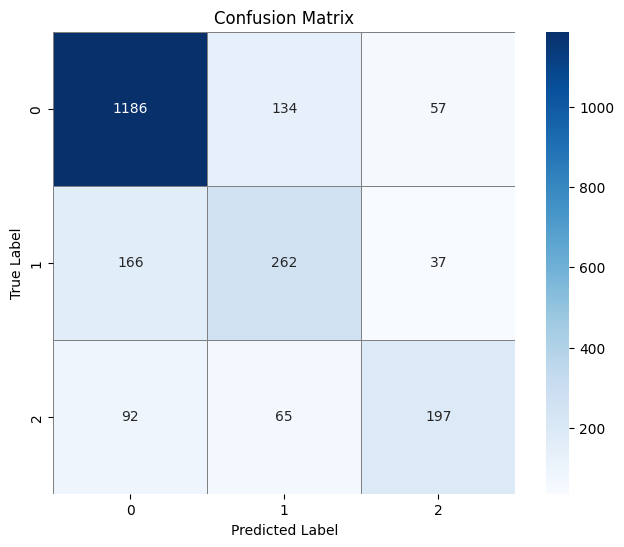

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1377
           1       0.57      0.56      0.57       465
           2       0.68      0.56      0.61       354

    accuracy                           0.75      2196
   macro avg       0.69      0.66      0.67      2196
weighted avg       0.74      0.75      0.75      2196



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred, output_dict=False))

In [23]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained Logistic Regression model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_proba = lr.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred)

print("Categorical Cross Entropy Loss for LR:",log_loss(y_test,y_pred_proba))

[[7.65225738e-01 2.01374317e-01 3.33999451e-02]
 [9.67103640e-01 3.01447092e-02 2.75165061e-03]
 [4.14849672e-01 5.10317798e-01 7.48325298e-02]
 ...
 [2.28357691e-01 7.17312648e-01 5.43296612e-02]
 [3.91360924e-01 4.55886613e-01 1.52752463e-01]
 [9.88272587e-01 1.16083085e-02 1.19104585e-04]]
[0 0 1 ... 1 1 0]
[0 0 1 ... 1 1 0]
Categorical Cross Entropy Loss for LR: 0.5929758737030199


# K Nearest Neighbor Modeling for NLP

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN classifier
knn = KNeighborsClassifier()

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test)

In [25]:
# Calculate and display the accuracy scores of the trained KNN model
# on both the training and testing datasets.
# - knn.score(X_train, y_train): returns the mean accuracy on the training data.
# - knn.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for K Nearest Neighbor:", knn.score(X_train, y_train))
print("Testing Accuracy Score for K Nearest Neighbor:", knn.score(X_test, y_test))

Training Accuracy Score for K Nearest Neighbor: 0.7543394406943105
Testing Accuracy Score for K Nearest Neighbor: 0.6275045537340619


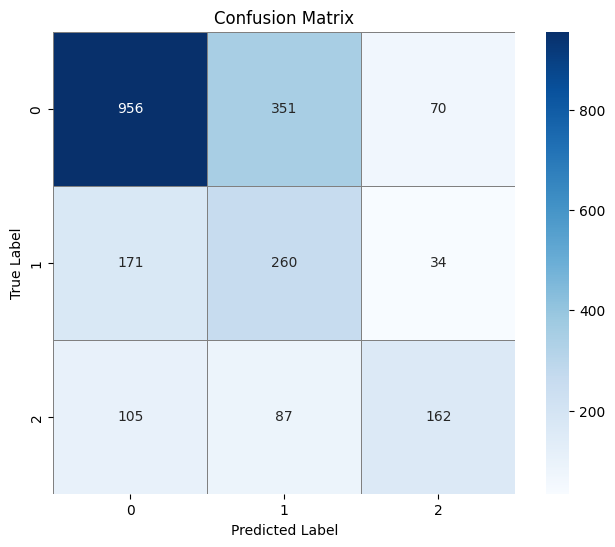

              precision    recall  f1-score   support

           0       0.78      0.69      0.73      1377
           1       0.37      0.56      0.45       465
           2       0.61      0.46      0.52       354

    accuracy                           0.63      2196
   macro avg       0.59      0.57      0.57      2196
weighted avg       0.66      0.63      0.64      2196



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_knn, output_dict=False))

In [27]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained KNN model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_knn_proba = knn.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_knn_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_knn_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_knn)

print("Categorical Cross Entropy for KNN:",log_loss(y_test, y_pred_knn_proba))

[[0.6 0.4 0. ]
 [0.6 0.2 0.2]
 [0.2 0.4 0.4]
 ...
 [0.  1.  0. ]
 [0.6 0.2 0.2]
 [0.8 0.2 0. ]]
[0 0 1 ... 1 0 0]
[0 0 1 ... 1 0 0]
Categorical Cross Entropy for KNN: 3.596826907394666


# Support Vector Machine Modeling for NLP

In [28]:
from sklearn.svm import SVC

# Create the Support Vector Machine (SVM) model
svm = SVC(probability=True)

# Fit the model to the training data
svm.fit(X_train, y_train)

# Predict on the test set
y_pred_svm = svm.predict(X_test)

In [29]:
# Calculate and display the accuracy scores of the trained SVM model
# on both the training and testing datasets.
# - svm.score(X_train, y_train): returns the mean accuracy on the training data.
# - svm.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for SVM:", svm.score(X_train, y_train))
print("Testing Accuracy Score for SVM:", svm.score(X_test, y_test))

Training Accuracy Score for SVM: 0.8416104146576664
Testing Accuracy Score for SVM: 0.7577413479052824


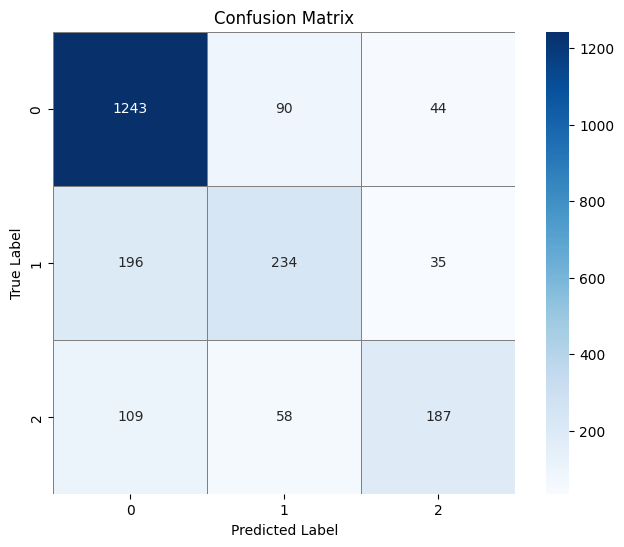

              precision    recall  f1-score   support

           0       0.80      0.90      0.85      1377
           1       0.61      0.50      0.55       465
           2       0.70      0.53      0.60       354

    accuracy                           0.76      2196
   macro avg       0.71      0.64      0.67      2196
weighted avg       0.75      0.76      0.75      2196



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_svm, output_dict=False))

In [31]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained SVM model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_svm_proba = svm.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_svm_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_svm_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_svm)

print("Categorical Cross Entropy for KNN:",log_loss(y_test, y_pred_svm_proba))

[[0.87376634 0.10632596 0.0199077 ]
 [0.88857807 0.07810397 0.03331796]
 [0.4356765  0.51365523 0.05066827]
 ...
 [0.14127277 0.79262882 0.06609841]
 [0.42067795 0.51709774 0.06222431]
 [0.95645358 0.03711599 0.00643044]]
[0 0 1 ... 1 1 0]
[0 0 1 ... 1 1 0]
Categorical Cross Entropy for KNN: 0.609364537163942


# XGBOOST Modeling for NLP

In [32]:
from xgboost import XGBClassifier

# Create the XGBoost model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Fit the model to the training data
xgb.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:48:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
# Calculate and display the accuracy scores of the trained XGB model
# on both the training and testing datasets.
# - svm.score(X_train, y_train): returns the mean accuracy on the training data.
# - svm.score(X_test, y_test): returns the mean accuracy on the testing data.

print("Training Accuracy Score for XGB:", xgb.score(X_train, y_train))
print("Testing Accuracy Score for XGB:", xgb.score(X_test, y_test))

Training Accuracy Score for XGB: 0.7855994856959178
Testing Accuracy Score for XGB: 0.7285974499089253


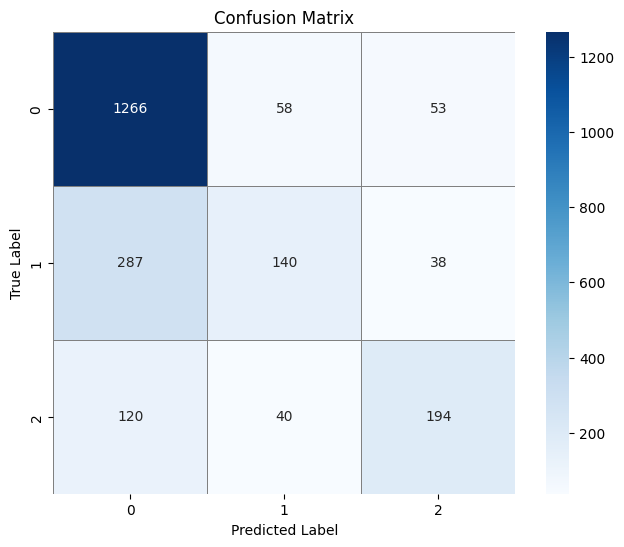

              precision    recall  f1-score   support

           0       0.76      0.92      0.83      1377
           1       0.59      0.30      0.40       465
           2       0.68      0.55      0.61       354

    accuracy                           0.73      2196
   macro avg       0.68      0.59      0.61      2196
weighted avg       0.71      0.73      0.70      2196



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix as a heatmap with additional parameters for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # Annotate cells with numeric values
    fmt='d',              # Integer formatting for annotations
    cmap='Blues',         # Color map
    linewidths=0.5,       # Add lines between cells
    linecolor='gray',     # Color of the lines
    cbar=True,            # Show color bar
    square=True           # Make cells square-shaped
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display the classification report for precision, recall, f1-score, and support
print(classification_report(y_test, y_pred_xgb, output_dict=False))

In [35]:
from sklearn.metrics import log_loss

# Predict class probabilities for the test set using the trained KNN model.
# - y_pred_proba: a 2D numpy array of shape (n_samples, n_classes), where each row contains
#   the predicted probabilities for each class for a given test sample.
y_pred_xgb_proba = xgb.predict_proba(X_test)

# Display the predicted probabilities for each class for all test samples.
print(y_pred_xgb_proba)

# For each test sample, find the index (class label) of the class with the highest predicted probability.
# This is equivalent to the predicted class label for each sample.
print(np.argmax(y_pred_xgb_proba, axis=1))

# Display the predicted class labels for the test set as predicted by the model.
# This should match the output of np.argmax(y_pred_proba, axis=1).
print(y_pred_xgb)

print("Categorical Cross Entropy:",log_loss(y_test, y_pred_xgb_proba))

[[7.97901094e-01 1.59441262e-01 4.26576138e-02]
 [8.52072239e-01 1.00336790e-01 4.75909561e-02]
 [4.18142021e-01 4.73579437e-01 1.08278535e-01]
 ...
 [2.98031777e-01 6.32066786e-01 6.99014813e-02]
 [4.71440196e-01 3.94926667e-01 1.33633152e-01]
 [9.85268235e-01 1.39870867e-02 7.44690653e-04]]
[0 0 1 ... 1 0 0]
[0 0 1 ... 1 0 0]
Categorical Cross Entropy: 0.6061611825818437


# Naive Bayes Modeling for NLP

In [36]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb = MultinomialNB()

# Train
nb.fit(X_train, y_train)

# Predict
y_pred_nb = nb.predict(X_test)

# Accuracy
print("Training Accuracy Score for Naive Bayes:", nb.score(X_train, y_train))
print("Testing Accuracy Score for Naive Bayes:", nb.score(X_test, y_test))


Training Accuracy Score for Naive Bayes: 0.7395531983285117
Testing Accuracy Score for Naive Bayes: 0.7099271402550091


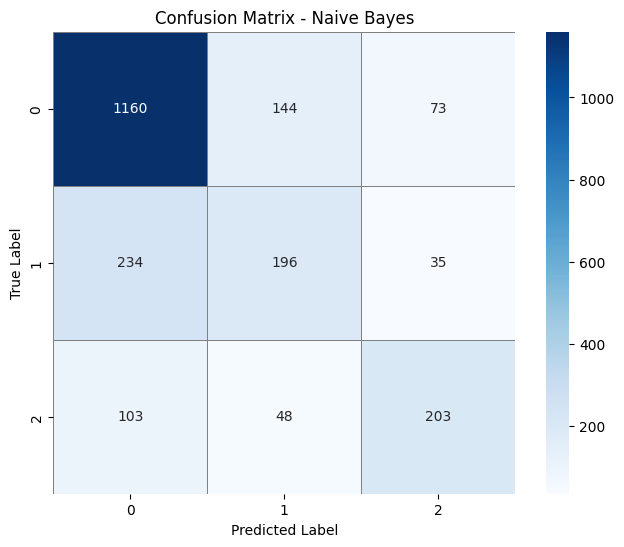

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [38]:
# Classification Report
print(classification_report(y_test, y_pred_nb))

# Log Loss
y_pred_nb_proba = nb.predict_proba(X_test)
print("Categorical Cross Entropy for Naive Bayes:",
      log_loss(y_test, y_pred_nb_proba))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81      1377
           1       0.51      0.42      0.46       465
           2       0.65      0.57      0.61       354

    accuracy                           0.71      2196
   macro avg       0.64      0.61      0.63      2196
weighted avg       0.70      0.71      0.70      2196

Categorical Cross Entropy for Naive Bayes: 0.7573327499322866


# Random Forest Modeling for NLP

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

In [40]:
# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Training Accuracy Score for Random Forest:", rf.score(X_train, y_train))
print("Testing Accuracy Score for Random Forest:", rf.score(X_test, y_test))


Training Accuracy Score for Random Forest: 0.9614271938283511
Testing Accuracy Score for Random Forest: 0.7190346083788707


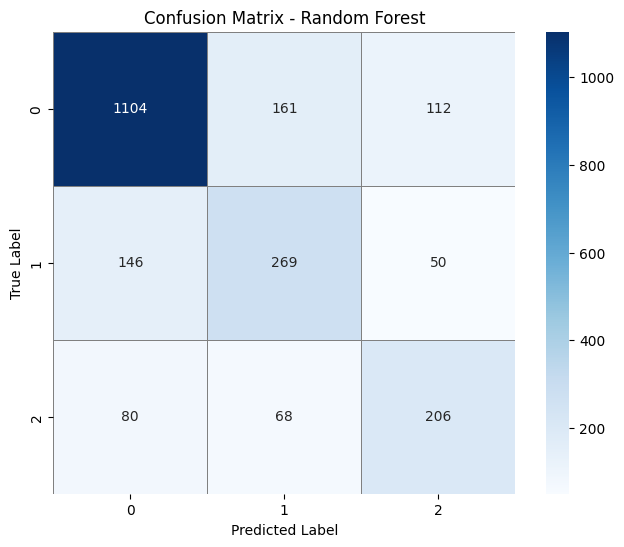

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [42]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

# Log Loss
y_pred_rf_proba = rf.predict_proba(X_test)
print("Categorical Cross Entropy for Random Forest:",
      log_loss(y_test, y_pred_rf_proba))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1377
           1       0.54      0.58      0.56       465
           2       0.56      0.58      0.57       354

    accuracy                           0.72      2196
   macro avg       0.64      0.65      0.65      2196
weighted avg       0.73      0.72      0.72      2196

Categorical Cross Entropy for Random Forest: 0.8237369184775951


# Gradient Boosting Modeling for NLP

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)


In [44]:
# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Accuracy
print("Training Accuracy Score for Gradient Boosting:", gb.score(X_train, y_train))
print("Testing Accuracy Score for Gradient Boosting:", gb.score(X_test, y_test))

Training Accuracy Score for Gradient Boosting: 0.798055287688846
Testing Accuracy Score for Gradient Boosting: 0.7235883424408015


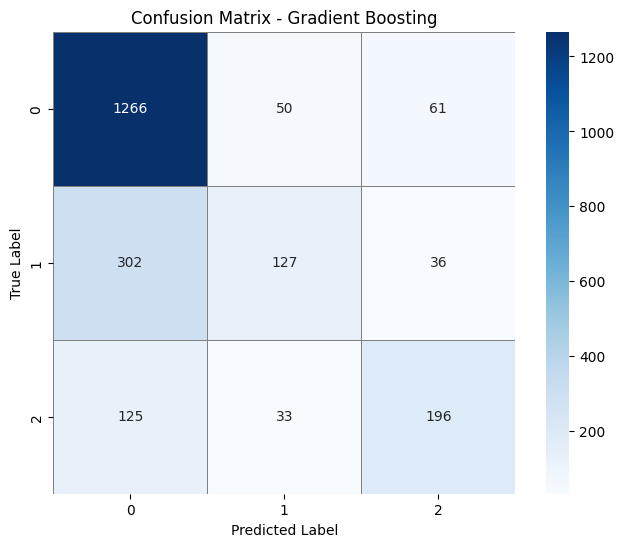

In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [46]:
# Classification Report
print(classification_report(y_test, y_pred_gb))

# Log Loss
y_pred_gb_proba = gb.predict_proba(X_test)
print("Categorical Cross Entropy for Gradient Boosting:",
      log_loss(y_test, y_pred_gb_proba))

              precision    recall  f1-score   support

           0       0.75      0.92      0.82      1377
           1       0.60      0.27      0.38       465
           2       0.67      0.55      0.61       354

    accuracy                           0.72      2196
   macro avg       0.67      0.58      0.60      2196
weighted avg       0.70      0.72      0.69      2196

Categorical Cross Entropy for Gradient Boosting: 0.6247464402210747


# Voting Ensemble Modeling for NLP

In [47]:
from sklearn.ensemble import VotingClassifier

# Create ensemble
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC(probability=True)),
        ('rf', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42
        ))
    ],
    voting='soft'
)

In [48]:
# Train
voting.fit(X_train, y_train)

# Predict
y_pred_voting = voting.predict(X_test)

# Accuracy
print("Training Accuracy Score for Voting Ensemble:",
      voting.score(X_train, y_train))
print("Testing Accuracy Score for Voting Ensemble:",
      voting.score(X_test, y_test))

Training Accuracy Score for Voting Ensemble: 0.8816297010607522
Testing Accuracy Score for Voting Ensemble: 0.7600182149362478


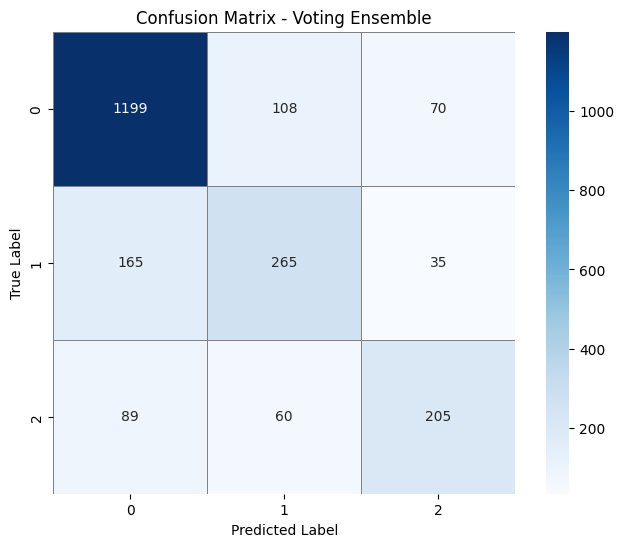

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_voting)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Voting Ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [50]:
# Classification Report
print(classification_report(y_test, y_pred_voting))

# Log Loss
y_pred_voting_proba = voting.predict_proba(X_test)
print("Categorical Cross Entropy for Voting Ensemble:",
      log_loss(y_test, y_pred_voting_proba))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1377
           1       0.61      0.57      0.59       465
           2       0.66      0.58      0.62       354

    accuracy                           0.76      2196
   macro avg       0.70      0.67      0.69      2196
weighted avg       0.75      0.76      0.76      2196

Categorical Cross Entropy for Voting Ensemble: 0.5947234101115445


# Decision Tree Modeling for NLP

In [51]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [52]:
# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
print("Training Accuracy Score for Decision Tree:", dt.score(X_train, y_train))
print("Testing Accuracy Score for Decision Tree:", dt.score(X_test, y_test))

Training Accuracy Score for Decision Tree: 0.7057216329154613
Testing Accuracy Score for Decision Tree: 0.6798724954462659


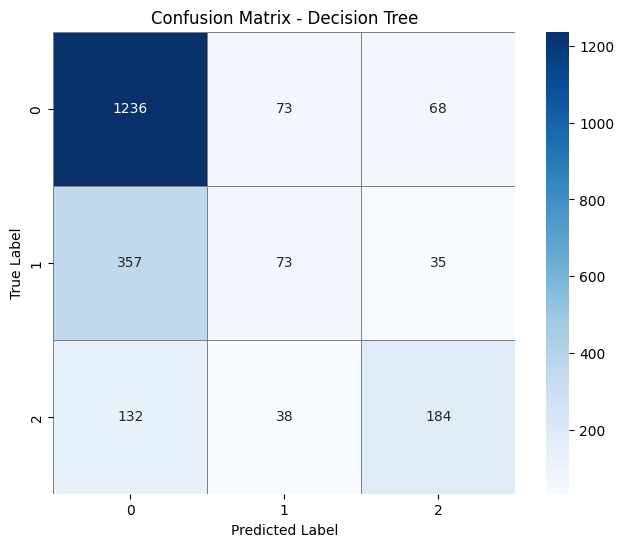

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [54]:
# Classification Report
print(classification_report(y_test, y_pred_dt))

# Log Loss
y_pred_dt_proba = dt.predict_proba(X_test)
print("Categorical Cross Entropy for Decision Tree:",
      log_loss(y_test, y_pred_dt_proba))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1377
           1       0.40      0.16      0.22       465
           2       0.64      0.52      0.57       354

    accuracy                           0.68      2196
   macro avg       0.58      0.52      0.53      2196
weighted avg       0.64      0.68      0.64      2196

Categorical Cross Entropy for Decision Tree: 1.2557339696519336


# AdaBoost Modeling for NLP

In [55]:
from sklearn.ensemble import AdaBoostClassifier

# Create the model
ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

In [56]:
# Train
ada.fit(X_train, y_train)

# Predict
y_pred_ada = ada.predict(X_test)

# Accuracy
print("Training Accuracy Score for AdaBoost:", ada.score(X_train, y_train))
print("Testing Accuracy Score for AdaBoost:", ada.score(X_test, y_test))


Training Accuracy Score for AdaBoost: 0.6557377049180327
Testing Accuracy Score for AdaBoost: 0.6543715846994536


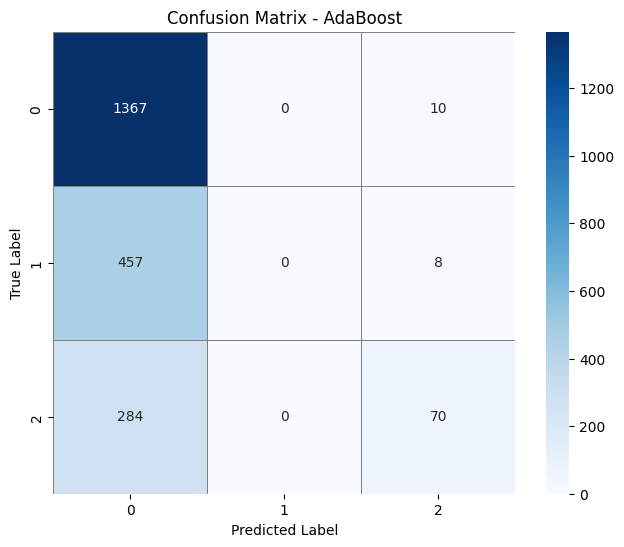

In [57]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [58]:
# Classification Report
print(classification_report(y_test, y_pred_ada))

# Log Loss
y_pred_ada_proba = ada.predict_proba(X_test)
print("Categorical Cross Entropy for AdaBoost:",
      log_loss(y_test, y_pred_ada_proba))

              precision    recall  f1-score   support

           0       0.65      0.99      0.78      1377
           1       0.00      0.00      0.00       465
           2       0.80      0.20      0.32       354

    accuracy                           0.65      2196
   macro avg       0.48      0.40      0.37      2196
weighted avg       0.53      0.65      0.54      2196



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Categorical Cross Entropy for AdaBoost: 0.9989735361943656


# Linear SVC Modeling for NLP

In [59]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Create the model
# CalibratedClassifierCV is needed to get probabilities
linear_svc = CalibratedClassifierCV(
    LinearSVC(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    )
)


In [60]:
# Train
linear_svc.fit(X_train, y_train)

# Predict
y_pred_lsvc = linear_svc.predict(X_test)

# Accuracy
print("Training Accuracy Score for Linear SVC:",
      linear_svc.score(X_train, y_train))
print("Testing Accuracy Score for Linear SVC:",
      linear_svc.score(X_test, y_test))

Training Accuracy Score for Linear SVC: 0.7703310832529733
Testing Accuracy Score for Linear SVC: 0.7413479052823315


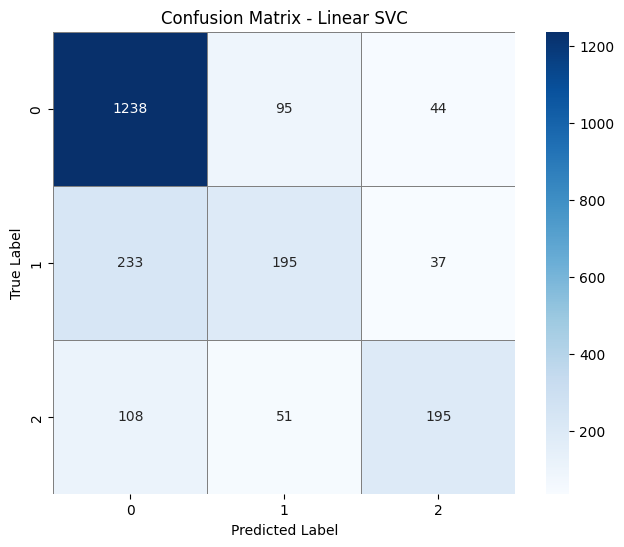

In [61]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lsvc)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - Linear SVC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [62]:
# Classification Report
print(classification_report(y_test, y_pred_lsvc))

# Log Loss
y_pred_lsvc_proba = linear_svc.predict_proba(X_test)
print("Categorical Cross Entropy for Linear SVC:",
      log_loss(y_test, y_pred_lsvc_proba))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84      1377
           1       0.57      0.42      0.48       465
           2       0.71      0.55      0.62       354

    accuracy                           0.74      2196
   macro avg       0.69      0.62      0.65      2196
weighted avg       0.73      0.74      0.73      2196

Categorical Cross Entropy for Linear SVC: 0.5948200857057346


# BERT Modeling for NLP

In [63]:
import torch
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import (
    Dataset,
    DataLoader,
    RandomSampler,
    SequentialSampler
)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [64]:
# Prepare Data
X_bert = df["text"].values
y_bert = y_encoded

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert,
    test_size=0.15,
    shuffle=True,
    stratify=y_bert,
    random_state=42
)
print(f"Train: {len(X_train_bert)} | Test: {len(X_test_bert)}")

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("✅ Tokenizer loaded")

# Dataset Class
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

Train: 12444 | Test: 2196


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer loaded


In [65]:
# DataLoaders
BATCH_SIZE = 32
train_dataset = TweetDataset(X_train_bert, y_train_bert, tokenizer)
test_dataset  = TweetDataset(X_test_bert,  y_test_bert,  tokenizer)
train_loader  = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=BATCH_SIZE
)
test_loader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=BATCH_SIZE
)
print("✅ DataLoaders created")

# Load BERT
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)
model_bert.to(device)
print("✅ BERT model loaded")

✅ DataLoaders created
Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded


In [66]:
# Training Setup
EPOCHS = 3
LEARNING_RATE = 2e-5
optimizer = AdamW(
    model_bert.parameters(),
    lr=LEARNING_RATE,
    eps=1e-8
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_loader) * EPOCHS
)

# Train Function
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        model.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        logits = outputs.logits
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        preds    = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

In [67]:
# Evaluate Function
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    all_preds  = []
    all_labels = []
    all_probs  = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss   = outputs.loss
            logits = outputs.logits
            total_loss += loss.item()
            probs  = torch.softmax(logits, dim=1)
            preds  = torch.argmax(logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss/len(loader), correct/total, \
           all_preds, all_labels, all_probs

In [68]:
# Training Loop
print("\n" + "="*50)
print("Starting BERT Training...")
print("="*50)

train_accuracies = []
test_accuracies  = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*30)
    train_loss, train_acc = train_epoch(
        model_bert, train_loader,
        optimizer, scheduler, device
    )
    test_loss, test_acc, preds, labels_out, probs = evaluate(
        model_bert, test_loader, device
    )
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

print("\n BERT Training Complete!")


Starting BERT Training...

Epoch 1/3
------------------------------
Train Loss: 0.5020 | Train Acc: 0.8002
Test  Loss: 0.4209 | Test  Acc: 0.8365

Epoch 2/3
------------------------------
Train Loss: 0.3155 | Train Acc: 0.8836
Test  Loss: 0.4209 | Test  Acc: 0.8493

Epoch 3/3
------------------------------
Train Loss: 0.2225 | Train Acc: 0.9259
Test  Loss: 0.4617 | Test  Acc: 0.8424

 BERT Training Complete!



Final BERT Test Accuracy : 0.8424
Final BERT Log Loss      : 0.4619

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1377
           1       0.69      0.71      0.70       465
           2       0.80      0.73      0.76       354

    accuracy                           0.84      2196
   macro avg       0.80      0.79      0.79      2196
weighted avg       0.84      0.84      0.84      2196



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


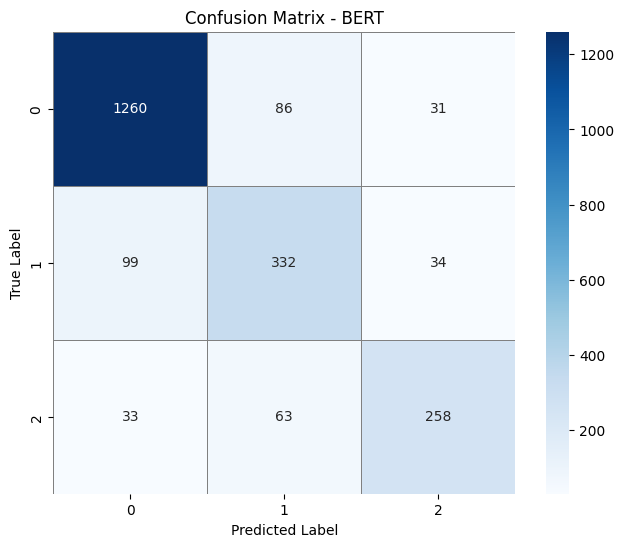

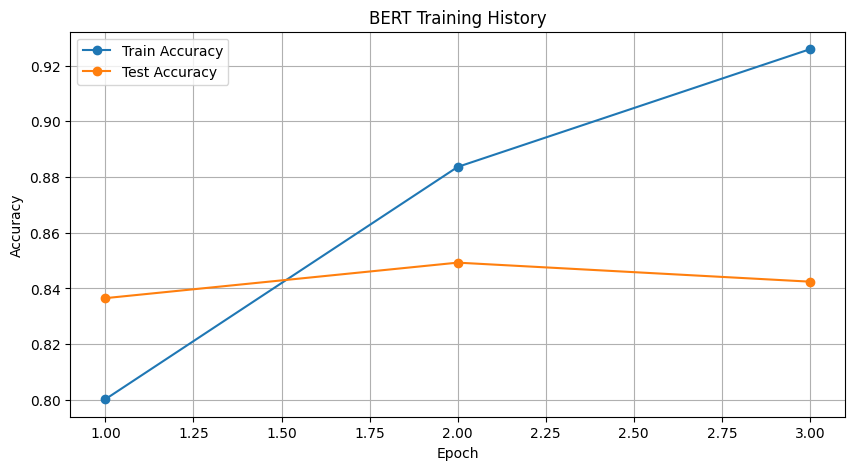

In [69]:
# Final Evaluation
_, _, y_pred_bert, y_true_bert, y_proba_bert = evaluate(
    model_bert, test_loader, device
)

bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)
bert_logloss  = log_loss(y_true_bert, y_proba_bert)

print(f"\nFinal BERT Test Accuracy : {bert_accuracy:.4f}")
print(f"Final BERT Log Loss      : {bert_logloss:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_bert, y_pred_bert))

# Confusion Matrix
cm = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar=True,
    square=True
)
plt.title('Confusion Matrix - BERT')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Training History
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_accuracies,
         marker='o', label='Train Accuracy')
plt.plot(range(1, EPOCHS+1), test_accuracies,
         marker='o', label='Test Accuracy')
plt.title('BERT Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Documenting the Results of All Machine Learning Models

In [70]:
from sklearn.metrics import log_loss

# -------------------------------------------------------
# Calculate all accuracies
# -------------------------------------------------------
testing_accuracy_lr     = lr.score(X_test, y_test)
testing_accuracy_knn    = knn.score(X_test, y_test)
testing_accuracy_svm    = svm.score(X_test, y_test)
testing_accuracy_xgb    = xgb.score(X_test, y_test)
testing_accuracy_nb     = nb.score(X_test, y_test)
testing_accuracy_rf     = rf.score(X_test, y_test)
testing_accuracy_gb     = gb.score(X_test, y_test)
testing_accuracy_voting = voting.score(X_test, y_test)
testing_accuracy_dt     = dt.score(X_test, y_test)
testing_accuracy_ada    = ada.score(X_test, y_test)
testing_accuracy_lsvc   = linear_svc.score(X_test, y_test)

# -------------------------------------------------------
# Calculate all log losses
# -------------------------------------------------------
testing_logloss_lr     = log_loss(y_test, y_pred_proba)
testing_logloss_knn    = log_loss(y_test, y_pred_knn_proba)
testing_logloss_svm    = log_loss(y_test, y_pred_svm_proba)
testing_logloss_xgb    = log_loss(y_test, y_pred_xgb_proba)
testing_logloss_nb     = log_loss(y_test, y_pred_nb_proba)
testing_logloss_rf     = log_loss(y_test, y_pred_rf_proba)
testing_logloss_gb     = log_loss(y_test, y_pred_gb_proba)
testing_logloss_voting = log_loss(y_test, y_pred_voting_proba)
testing_logloss_dt     = log_loss(y_test, y_pred_dt_proba)
testing_logloss_ada    = log_loss(y_test, y_pred_ada_proba)
testing_logloss_lsvc   = log_loss(y_test, y_pred_lsvc_proba)

# -------------------------------------------------------
# Build results DataFrame
# -------------------------------------------------------
df_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "XGBoost",
        "Naive Bayes",
        "Random Forest",
        "Gradient Boosting",
        "Voting Ensemble",
        "Decision Tree",
        "AdaBoost",
        "Linear SVC"
    ],
    "Accuracy": [
        testing_accuracy_lr,
        testing_accuracy_knn,
        testing_accuracy_svm,
        testing_accuracy_xgb,
        testing_accuracy_nb,
        testing_accuracy_rf,
        testing_accuracy_gb,
        testing_accuracy_voting,
        testing_accuracy_dt,
        testing_accuracy_ada,
        testing_accuracy_lsvc
    ],
    "LogLoss": [
        testing_logloss_lr,
        testing_logloss_knn,
        testing_logloss_svm,
        testing_logloss_xgb,
        testing_logloss_nb,
        testing_logloss_rf,
        testing_logloss_gb,
        testing_logloss_voting,
        testing_logloss_dt,
        testing_logloss_ada,
        testing_logloss_lsvc
    ]
})



In [71]:
print("Models Performance Results on Testing Set")
print("#"*55)
print(df_results.to_string(index=False).upper())
print("#"*55)

Models Performance Results on Testing Set
#######################################################
              MODEL  ACCURACY  LOGLOSS
LOGISTIC REGRESSION  0.749089 0.592976
                KNN  0.627505 3.596827
                SVM  0.757741 0.609365
            XGBOOST  0.728597 0.606161
        NAIVE BAYES  0.709927 0.757333
      RANDOM FOREST  0.719035 0.823737
  GRADIENT BOOSTING  0.723588 0.624746
    VOTING ENSEMBLE  0.760018 0.594723
      DECISION TREE  0.679872 1.255734
           ADABOOST  0.654372 0.998974
         LINEAR SVC  0.741348 0.594820
#######################################################


# Final Bar Chart — All 12 Models

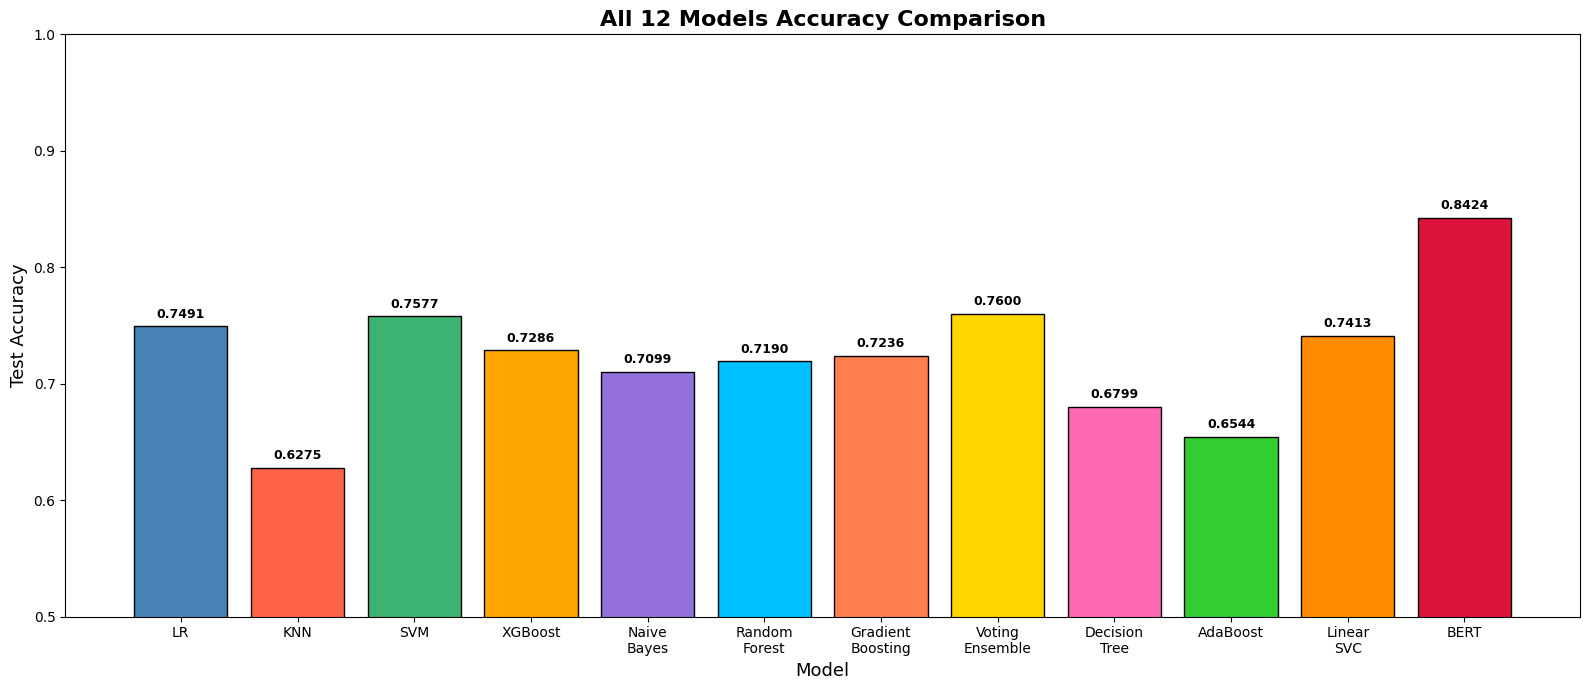

In [72]:
models = [
    "LR", "KNN", "SVM", "XGBoost",
    "Naive\nBayes", "Random\nForest",
    "Gradient\nBoosting", "Voting\nEnsemble",
    "Decision\nTree", "AdaBoost",
    "Linear\nSVC", "BERT"
]

accuracies = [
    testing_accuracy_lr,
    testing_accuracy_knn,
    testing_accuracy_svm,
    testing_accuracy_xgb,
    testing_accuracy_nb,
    testing_accuracy_rf,
    testing_accuracy_gb,
    testing_accuracy_voting,
    testing_accuracy_dt,
    testing_accuracy_ada,
    testing_accuracy_lsvc,
    bert_accuracy
]

colors = [
    'steelblue', 'tomato', 'mediumseagreen', 'orange',
    'mediumpurple', 'deepskyblue', 'coral', 'gold',
    'hotpink', 'limegreen', 'darkorange', 'crimson'
]

plt.figure(figsize=(16, 7))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')
plt.ylim(0.5, 1.0)
plt.title('All 12 Models Accuracy Comparison',
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Real-Time Sentiment Prediction — Chatbot

In [73]:
def program_nlp(text: str, model) -> str:
    preprocessed_text = preprocess_text(text)
    features_extracted = bow.transform([preprocessed_text])
    output = model.predict(features_extracted)
    return l2emotion[output[0]]

print("Chatbot Ready! Using best model (SVM)")
print("Type 'exit' to quit\n")

while True:
    user_input = input("Tell me your opinion: ")
    if user_input.lower() == 'exit':
        print("Goodbye! See you again ")
        break
    emotion = program_nlp(user_input, svm)
    print(f"Sentiment Detected: {emotion.upper()}\n")

Chatbot Ready! Using best model (SVM)
Type 'exit' to quit

Tell me your opinion: good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


ValueError: cannot use sparse input in 'SVC' trained on dense data